Cellule 1 — Installation des bibliothèques

In [3]:
!pip install rasterio geopandas shapely opencv-python scikit-image pandas numpy matplotlib tqdm -q

Cellule 2 — Importation des bibliothèques

In [4]:
import json
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import rasterio
from rasterio.features import rasterize
import geopandas as gpd
from shapely.geometry import LineString, MultiLineString, Polygon, MultiPolygon

from tqdm import tqdm

warnings.filterwarnings("ignore")

print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


Cellule 3 — Configuration générale

In [5]:
SEED = 42
np.random.seed(SEED)

# Dossiers du projet
BASE_DIR = Path("../dattest")
RAW_DIR = BASE_DIR / "rawtest"
IMAGES_DIR = RAW_DIR / "images"
ANNOTATIONS_DIR = RAW_DIR / "annotations"
METADATA_DIR = BASE_DIR / "metadata"

# Fichier généré par le premier notebook Acquisition
METADATA_PATH = METADATA_DIR / "metadata_pairs.csv"

# Dossier de sortie du preprocessing
PROCESSED_DIR = BASE_DIR / "processedtest"
PATCHES_DIR = PROCESSED_DIR / "patches"
PREVIEW_DIR = PROCESSED_DIR / "previews"

PATCHES_DIR.mkdir(parents=True, exist_ok=True)
PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

# Paramètres patches
PATCH_SIZE = 256
STRIDE = 128

# Seuil minimal pour garder un patch positif
MIN_POSITIVE_RATIO = 0.0005

# Dilatation des routes
# Important : dans l'ancien preprocessing, les routes étaient trop fines.
ROAD_DILATION_KERNEL = 5
ROAD_DILATION_ITERATIONS = 1

# Garder seulement une partie des patches vides
KEEP_EMPTY_PROBABILITY = 0.15

print("Configuration terminée.")
print("Metadata :", METADATA_PATH)
print("Sortie :", PROCESSED_DIR)

Configuration terminée.
Metadata : ..\dattest\metadata\metadata_pairs.csv
Sortie : ..\dattest\processedtest


Cellule 4 — Charger les métadonnées

In [6]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Fichier metadata introuvable : {METADATA_PATH}\n"
        "Exécute d'abord le premier notebook d'acquisition."
    )

metadata_df = pd.read_csv(METADATA_PATH)

required_cols = [
    "tile_id",
    "local_image_path",
    "local_annotation_path",
    "split"
]

missing_cols = [c for c in required_cols if c not in metadata_df.columns]

if missing_cols:
    raise ValueError(f"Colonnes manquantes dans metadata_pairs.csv : {missing_cols}")

print("Nombre total d'images dans metadata :", len(metadata_df))

print("\nRépartition split :")
print(metadata_df["split"].value_counts())

display(metadata_df.head())

Nombre total d'images dans metadata : 100

Répartition split :
split
train    70
val      15
test     15
Name: count, dtype: int64


,image_s3_key,tile_id,image_filename,annotation_s3_key,annotation_filename,split,local_image_path,local_annotation_path,image_exists,annotation_exists
0,spacenet/SN8_floods/Germany_Training_Public/PO...,0_37_68,10500500E6DD3C00_0_37_68.tif,spacenet/SN8_floods/Germany_Training_Public/an...,0_37_68.geojson,train,..\dattest\rawtest\images\10500500E6DD3C00_0_3...,..\dattest\rawtest\annotations\0_37_68.geojson,True,True
1,spacenet/SN8_floods/Germany_Training_Public/PO...,0_18_67,1040050035DC3B00_0_18_67.tif,spacenet/SN8_floods/Germany_Training_Public/an...,0_18_67.geojson,train,..\dattest\rawtest\images\1040050035DC3B00_0_1...,..\dattest\rawtest\annotations\0_18_67.geojson,True,True
2,spacenet/SN8_floods/Germany_Training_Public/PO...,0_29_61,10500500E6DD3C00_0_29_61.tif,spacenet/SN8_floods/Germany_Training_Public/an...,0_29_61.geojson,train,..\dattest\rawtest\images\10500500E6DD3C00_0_2...,..\dattest\rawtest\annotations\0_29_61.geojson,True,True
3,spacenet/SN8_floods/Germany_Training_Public/PO...,0_32_69,10500500E6DD3C00_0_32_69.tif,spacenet/SN8_floods/Germany_Training_Public/an...,0_32_69.geojson,train,..\dattest\rawtest\images\10500500E6DD3C00_0_3...,..\dattest\rawtest\annotations\0_32_69.geojson,True,True
4,spacenet/SN8_floods/Germany_Training_Public/PO...,0_21_65,1040050035DC3B00_0_21_65.tif,spacenet/SN8_floods/Germany_Training_Public/an...,0_21_65.geojson,train,..\dattest\rawtest\images\1040050035DC3B00_0_2...,..\dattest\rawtest\annotations\0_21_65.geojson,True,True


Cellule 5 — Vérifier que les fichiers existent

In [7]:
metadata_df["image_exists"] = metadata_df["local_image_path"].apply(
    lambda p: Path(p).exists()
)

metadata_df["annotation_exists"] = metadata_df["local_annotation_path"].apply(
    lambda p: Path(p).exists()
)

print("Images existantes :", metadata_df["image_exists"].sum(), "/", len(metadata_df))
print("Annotations existantes :", metadata_df["annotation_exists"].sum(), "/", len(metadata_df))

missing_df = metadata_df[
    (~metadata_df["image_exists"]) | (~metadata_df["annotation_exists"])
]

if len(missing_df) > 0:
    print("Attention : certains fichiers sont manquants.")
    display(missing_df)
else:
    print("Tous les fichiers nécessaires sont disponibles.")

Images existantes : 100 / 100
Annotations existantes : 100 / 100
Tous les fichiers nécessaires sont disponibles.


Cellule 6 — Fonctions utilitaires pour lire les images

In [8]:
def normalize_band(band):
    """
    Normalise une bande raster entre 0 et 1 avec clipping robuste.
    """
    band = band.astype(np.float32)
    
    valid = band[np.isfinite(band)]
    
    if valid.size == 0:
        return np.zeros_like(band, dtype=np.float32)
    
    p2, p98 = np.percentile(valid, (2, 98))
    
    if p98 <= p2:
        return np.zeros_like(band, dtype=np.float32)
    
    band = np.clip(band, p2, p98)
    band = (band - p2) / (p98 - p2)
    
    return band.astype(np.float32)


def read_rgb_image(image_path):
    """
    Lit une image GeoTIFF et retourne :
    - image RGB normalisée entre 0 et 1
    - profil rasterio
    - transform géographique
    - shape image
    """
    with rasterio.open(image_path) as src:
        count = src.count
        
        if count >= 3:
            img = src.read([1, 2, 3])
        elif count == 1:
            one = src.read(1)
            img = np.stack([one, one, one], axis=0)
        else:
            raise ValueError(f"Image avec nombre de bandes non supporté : {count}")
        
        # C, H, W vers H, W, C
        img = np.transpose(img, (1, 2, 0))
        
        img_norm = np.zeros_like(img, dtype=np.float32)
        
        for c in range(3):
            img_norm[:, :, c] = normalize_band(img[:, :, c])
        
        profile = src.profile.copy()
        transform = src.transform
        shape = (src.height, src.width)
    
    return img_norm, profile, transform, shape


def pad_to_min_size(array, min_size=256):
    """
    Ajoute du padding si une image ou un masque est plus petit que min_size.
    """
    h, w = array.shape[:2]
    
    pad_h = max(0, min_size - h)
    pad_w = max(0, min_size - w)
    
    if pad_h == 0 and pad_w == 0:
        return array
    
    if array.ndim == 3:
        return np.pad(
            array,
            ((0, pad_h), (0, pad_w), (0, 0)),
            mode="constant"
        )
    else:
        return np.pad(
            array,
            ((0, pad_h), (0, pad_w)),
            mode="constant"
        )

Cellule 7 — Fonctions pour lire les annotations et créer les masques

In [9]:
def is_road_feature(row):
    """
    Détecte si une géométrie correspond à une route.
    """
    geom = row.geometry
    
    if geom is None:
        return False
    
    if not isinstance(geom, (LineString, MultiLineString)):
        return False
    
    # Dans SpaceNet 8, les routes ont souvent une propriété highway
    if "highway" in row.index:
        return pd.notna(row["highway"])
    
    # Fallback : si c'est une ligne, on la considère comme route
    return True


def is_building_feature(row):
    """
    Détecte si une géométrie correspond à un bâtiment.
    """
    geom = row.geometry
    
    if geom is None:
        return False
    
    if not isinstance(geom, (Polygon, MultiPolygon)):
        return False
    
    # Dans SpaceNet 8, les bâtiments ont souvent building == yes
    if "building" in row.index:
        value = str(row["building"]).lower()
        return value in ["yes", "true", "1", "building"]
    
    # Fallback : si c'est un polygone, on le considère comme bâtiment
    return True


def read_annotation(annotation_path):
    """
    Lit un fichier GeoJSON avec GeoPandas.
    """
    try:
        gdf = gpd.read_file(annotation_path)
        return gdf
    except Exception as e:
        print(f"Erreur lecture annotation {annotation_path} : {e}")
        return gpd.GeoDataFrame(geometry=[])


def rasterize_geometries(geometries, out_shape, transform):
    """
    Rasterise une liste de géométries en masque binaire.
    """
    if len(geometries) == 0:
        return np.zeros(out_shape, dtype=np.uint8)
    
    shapes = [
        (geom, 1)
        for geom in geometries
        if geom is not None and not geom.is_empty
    ]
    
    if len(shapes) == 0:
        return np.zeros(out_shape, dtype=np.uint8)
    
    mask = rasterize(
        shapes=shapes,
        out_shape=out_shape,
        transform=transform,
        fill=0,
        default_value=1,
        dtype="uint8"
    )
    
    return mask


def dilate_mask(mask, kernel_size=5, iterations=1):
    """
    Épaissit un masque binaire.
    Très important pour les routes, car les LineString deviennent souvent trop fines.
    """
    if kernel_size <= 1:
        return mask.astype(np.uint8)
    
    kernel = np.ones((kernel_size, kernel_size), dtype=np.uint8)
    
    dilated = cv2.dilate(
        mask.astype(np.uint8),
        kernel,
        iterations=iterations
    )
    
    return (dilated > 0).astype(np.uint8)


def create_masks(annotation_path, out_shape, transform):
    """
    Crée deux masques :
    - road_mask
    - building_mask
    """
    gdf = read_annotation(annotation_path)
    
    if len(gdf) == 0:
        road_mask = np.zeros(out_shape, dtype=np.uint8)
        building_mask = np.zeros(out_shape, dtype=np.uint8)
        return road_mask, building_mask
    
    road_geoms = []
    building_geoms = []
    
    for _, row in gdf.iterrows():
        if is_road_feature(row):
            road_geoms.append(row.geometry)
        elif is_building_feature(row):
            building_geoms.append(row.geometry)
    
    road_mask = rasterize_geometries(
        road_geoms,
        out_shape,
        transform
    )
    
    building_mask = rasterize_geometries(
        building_geoms,
        out_shape,
        transform
    )
    
    # Correction importante : épaissir les routes
    road_mask = dilate_mask(
        road_mask,
        kernel_size=ROAD_DILATION_KERNEL,
        iterations=ROAD_DILATION_ITERATIONS
    )
    
    return road_mask, building_mask

Cellule 8 — Fonction de découpage en patches

In [10]:
def extract_patches(image, road_mask, building_mask, tile_id, split):
    """
    Découpe image + masques en patches.
    Retourne une liste de dictionnaires.
    """
    
    image = pad_to_min_size(image, PATCH_SIZE)
    road_mask = pad_to_min_size(road_mask, PATCH_SIZE)
    building_mask = pad_to_min_size(building_mask, PATCH_SIZE)
    
    h, w = road_mask.shape
    
    patches = []
    
    for y in range(0, h - PATCH_SIZE + 1, STRIDE):
        for x in range(0, w - PATCH_SIZE + 1, STRIDE):
            
            img_patch = image[
                y:y + PATCH_SIZE,
                x:x + PATCH_SIZE,
                :
            ]
            
            road_patch = road_mask[
                y:y + PATCH_SIZE,
                x:x + PATCH_SIZE
            ]
            
            building_patch = building_mask[
                y:y + PATCH_SIZE,
                x:x + PATCH_SIZE
            ]
            
            road_ratio = road_patch.mean()
            building_ratio = building_patch.mean()
            positive_ratio = max(road_ratio, building_ratio)
            
            # On garde :
            # - tous les patches avec routes ou bâtiments
            # - seulement une partie des patches vides
            keep_patch = False
            
            if positive_ratio >= MIN_POSITIVE_RATIO:
                keep_patch = True
            else:
                keep_patch = np.random.rand() < KEEP_EMPTY_PROBABILITY
            
            if keep_patch:
                patches.append({
                    "tile_id": tile_id,
                    "split": split,
                    "x": x,
                    "y": y,
                    "image": img_patch.astype(np.float32),
                    "road_mask": road_patch.astype(np.uint8)[..., np.newaxis],
                    "building_mask": building_patch.astype(np.uint8)[..., np.newaxis],
                    "road_ratio": float(road_ratio),
                    "building_ratio": float(building_ratio)
                })
    
    return patches

Cellule 9 — Test sur une seule image

Tile ID : 0_37_68
Image shape : (786, 786, 3)
Road mask shape : (786, 786)
Building mask shape : (786, 786)
Ratio routes : 0.03049550337004448
Ratio bâtiments : 0.05574655711594118


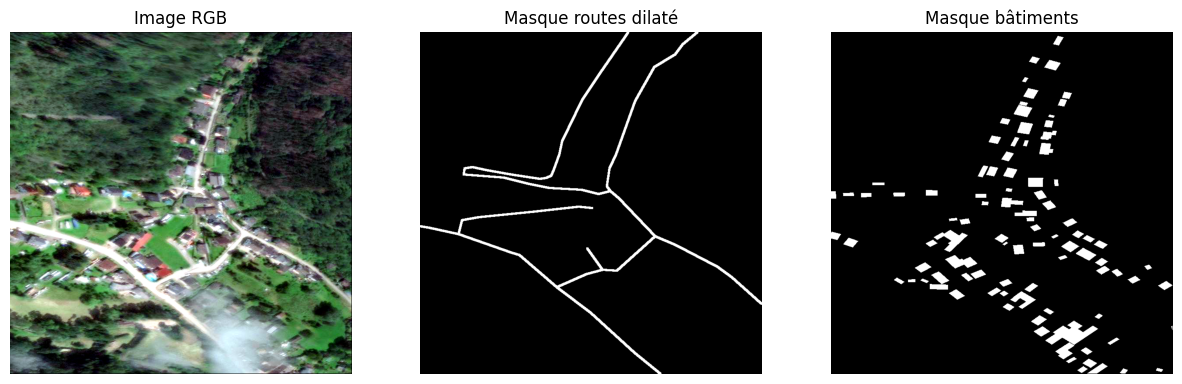

In [11]:
sample_row = metadata_df.iloc[0]

img, profile, transform, shape = read_rgb_image(
    sample_row["local_image_path"]
)

road_mask, building_mask = create_masks(
    sample_row["local_annotation_path"],
    out_shape=shape,
    transform=transform
)

print("Tile ID :", sample_row["tile_id"])
print("Image shape :", img.shape)
print("Road mask shape :", road_mask.shape)
print("Building mask shape :", building_mask.shape)
print("Ratio routes :", road_mask.mean())
print("Ratio bâtiments :", building_mask.mean())

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Image RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(road_mask, cmap="gray")
plt.title("Masque routes dilaté")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(building_mask, cmap="gray")
plt.title("Masque bâtiments")
plt.axis("off")

plt.show()

Cellule 10 — Préprocessing complet

In [12]:
all_patches = []
stats = []

for _, row in tqdm(
    metadata_df.iterrows(),
    total=len(metadata_df),
    desc="Préprocessing images"
):
    
    tile_id = row["tile_id"]
    split = row["split"]
    image_path = row["local_image_path"]
    annotation_path = row["local_annotation_path"]
    
    try:
        image, profile, transform, shape = read_rgb_image(image_path)
        
        road_mask, building_mask = create_masks(
            annotation_path,
            out_shape=shape,
            transform=transform
        )
        
        patches = extract_patches(
            image=image,
            road_mask=road_mask,
            building_mask=building_mask,
            tile_id=tile_id,
            split=split
        )
        
        all_patches.extend(patches)
        
        stats.append({
            "tile_id": tile_id,
            "split": split,
            "image_height": image.shape[0],
            "image_width": image.shape[1],
            "road_ratio_full_image": float(road_mask.mean()),
            "building_ratio_full_image": float(building_mask.mean()),
            "num_patches_kept": len(patches)
        })
        
    except Exception as e:
        print(f"Erreur sur {tile_id} : {e}")

stats_df = pd.DataFrame(stats)

print("Nombre total de patches générés :", len(all_patches))

print("\nPatches par split :")
print(pd.Series([p["split"] for p in all_patches]).value_counts())

display(stats_df.head())

Préprocessing images: 100%|██████████| 100/100 [00:18<00:00,  5.32it/s]

Nombre total de patches générés : 3360

Patches par split :
train    2354
test      587
val       419
Name: count, dtype: int64


,tile_id,split,image_height,image_width,road_ratio_full_image,building_ratio_full_image,num_patches_kept
0,0_37_68,train,786,786,0.030496,0.055747,24
1,0_18_67,train,1743,1743,0.008925,0.000000,81
2,0_29_61,train,785,785,0.013953,0.013602,21
3,0_32_69,train,786,785,0.001042,0.001467,8
4,0_21_65,train,1743,1743,0.009315,0.000000,73


Cellule 11 — Conversion en arrays par split

In [13]:
def patches_to_arrays(patches, split_name):
    """
    Convertit les patches d'un split en arrays NumPy.
    """
    split_patches = [
        p for p in patches
        if p["split"] == split_name
    ]
    
    X = np.array(
        [p["image"] for p in split_patches],
        dtype=np.float32
    )
    
    Y_roads = np.array(
        [p["road_mask"] for p in split_patches],
        dtype=np.uint8
    )
    
    Y_buildings = np.array(
        [p["building_mask"] for p in split_patches],
        dtype=np.uint8
    )
    
    meta = pd.DataFrame([
        {
            "tile_id": p["tile_id"],
            "split": p["split"],
            "x": p["x"],
            "y": p["y"],
            "road_ratio": p["road_ratio"],
            "building_ratio": p["building_ratio"]
        }
        for p in split_patches
    ])
    
    return X, Y_roads, Y_buildings, meta


X_train, Y_roads_train, Y_buildings_train, meta_train = patches_to_arrays(
    all_patches,
    "train"
)

X_val, Y_roads_val, Y_buildings_val, meta_val = patches_to_arrays(
    all_patches,
    "val"
)

X_test, Y_roads_test, Y_buildings_test, meta_test = patches_to_arrays(
    all_patches,
    "test"
)

print("Train :", X_train.shape, Y_roads_train.shape, Y_buildings_train.shape)
print("Val   :", X_val.shape, Y_roads_val.shape, Y_buildings_val.shape)
print("Test  :", X_test.shape, Y_roads_test.shape, Y_buildings_test.shape)

Train : (2354, 256, 256, 3) (2354, 256, 256, 1) (2354, 256, 256, 1)
Val   : (419, 256, 256, 3) (419, 256, 256, 1) (419, 256, 256, 1)
Test  : (587, 256, 256, 3) (587, 256, 256, 1) (587, 256, 256, 1)


Cellule 12 — Statistiques de qualité des masques

In [14]:
def count_positive_patches(Y):
    """
    Compte les patches qui contiennent au moins un pixel positif.
    """
    if len(Y) == 0:
        return 0
    
    return int(
        (Y.reshape(len(Y), -1).sum(axis=1) > 0).sum()
    )


summary = pd.DataFrame([
    {
        "split": "train",
        "nb_patches": len(X_train),
        "road_pixel_ratio": float(Y_roads_train.mean()) if len(Y_roads_train) else 0,
        "building_pixel_ratio": float(Y_buildings_train.mean()) if len(Y_buildings_train) else 0,
        "patches_with_roads": count_positive_patches(Y_roads_train),
        "patches_with_buildings": count_positive_patches(Y_buildings_train),
    },
    {
        "split": "val",
        "nb_patches": len(X_val),
        "road_pixel_ratio": float(Y_roads_val.mean()) if len(Y_roads_val) else 0,
        "building_pixel_ratio": float(Y_buildings_val.mean()) if len(Y_buildings_val) else 0,
        "patches_with_roads": count_positive_patches(Y_roads_val),
        "patches_with_buildings": count_positive_patches(Y_buildings_val),
    },
    {
        "split": "test",
        "nb_patches": len(X_test),
        "road_pixel_ratio": float(Y_roads_test.mean()) if len(Y_roads_test) else 0,
        "building_pixel_ratio": float(Y_buildings_test.mean()) if len(Y_buildings_test) else 0,
        "patches_with_roads": count_positive_patches(Y_roads_test),
        "patches_with_buildings": count_positive_patches(Y_buildings_test),
    }
])

display(summary)

print("Important : le ratio routes doit être meilleur que dans l'ancien preprocessing.")
print("Ancien résultat routes ≈ 0.004.")
print("Avec la dilatation, il doit normalement augmenter.")

,split,nb_patches,road_pixel_ratio,building_pixel_ratio,patches_with_roads,patches_with_buildings
0,train,2354,0.018306,0.031785,1758,753
1,val,419,0.018086,0.019652,306,90
2,test,587,0.017226,0.019960,419,233


Important : le ratio routes doit être meilleur que dans l'ancien preprocessing.
Ancien résultat routes ≈ 0.004.
Avec la dilatation, il doit normalement augmenter.


Cellule 13 — Visualiser quelques patches

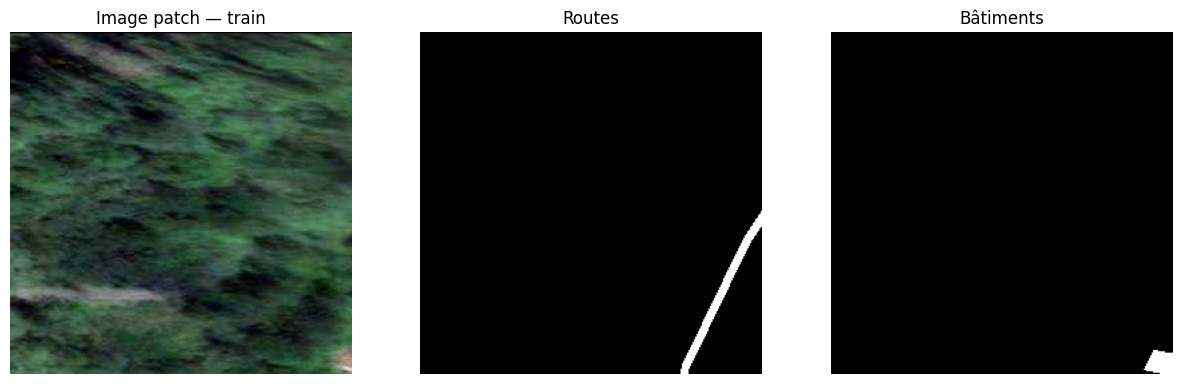

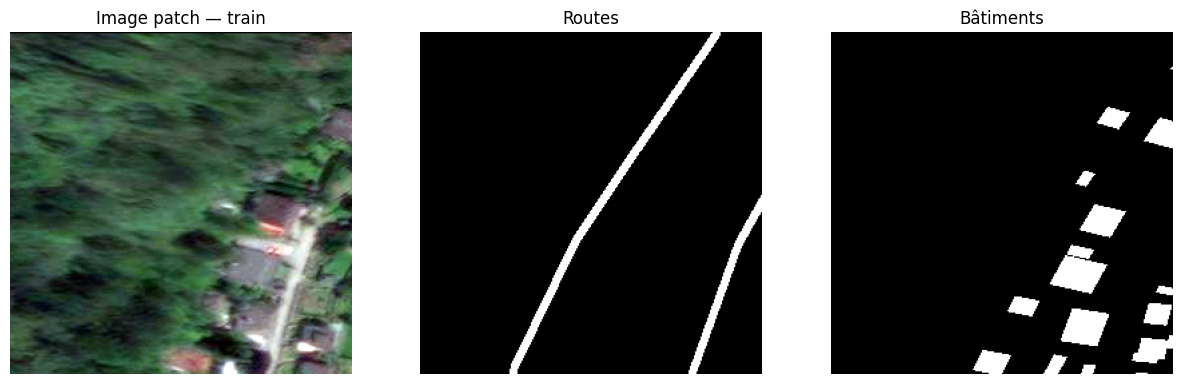

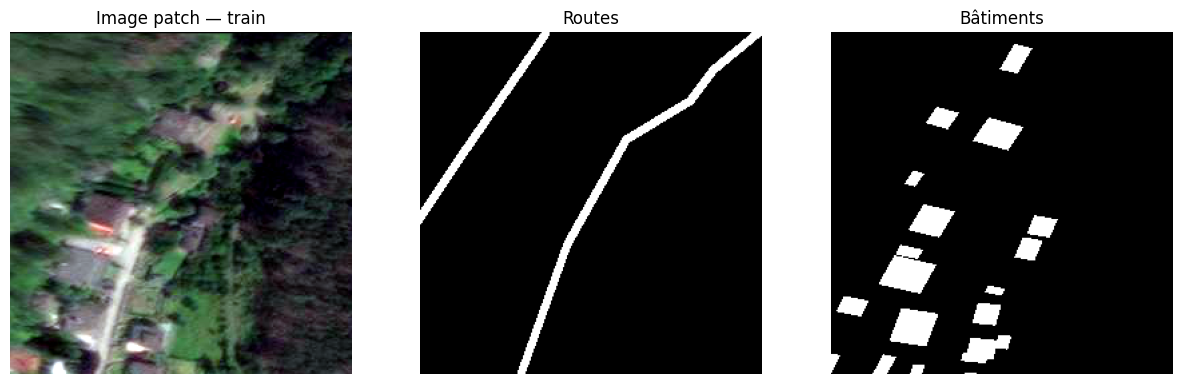

In [15]:
def show_patch(index, split_name="train"):
    """
    Affiche un patch image + masque routes + masque bâtiments.
    """
    if split_name == "train":
        X, Yr, Yb = X_train, Y_roads_train, Y_buildings_train
    elif split_name == "val":
        X, Yr, Yb = X_val, Y_roads_val, Y_buildings_val
    else:
        X, Yr, Yb = X_test, Y_roads_test, Y_buildings_test
    
    if len(X) == 0:
        print(f"Aucun patch dans le split {split_name}")
        return
    
    index = min(index, len(X) - 1)
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(X[index])
    plt.title(f"Image patch — {split_name}")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(Yr[index].squeeze(), cmap="gray")
    plt.title("Routes")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(Yb[index].squeeze(), cmap="gray")
    plt.title("Bâtiments")
    plt.axis("off")
    
    plt.show()


for i in range(3):
    show_patch(i, "train")

Cellule 14 — Sauvegarder les arrays .npy

In [16]:
# Train
np.save(PATCHES_DIR / "X_train.npy", X_train)
np.save(PATCHES_DIR / "Y_roads_train.npy", Y_roads_train)
np.save(PATCHES_DIR / "Y_buildings_train.npy", Y_buildings_train)

# Validation
np.save(PATCHES_DIR / "X_val.npy", X_val)
np.save(PATCHES_DIR / "Y_roads_val.npy", Y_roads_val)
np.save(PATCHES_DIR / "Y_buildings_val.npy", Y_buildings_val)

# Test
np.save(PATCHES_DIR / "X_test.npy", X_test)
np.save(PATCHES_DIR / "Y_roads_test.npy", Y_roads_test)
np.save(PATCHES_DIR / "Y_buildings_test.npy", Y_buildings_test)

# Métadonnées patches
meta_train.to_csv(PATCHES_DIR / "meta_train.csv", index=False)
meta_val.to_csv(PATCHES_DIR / "meta_val.csv", index=False)
meta_test.to_csv(PATCHES_DIR / "meta_test.csv", index=False)

# Statistiques
stats_df.to_csv(PROCESSED_DIR / "preprocessing_image_stats.csv", index=False)
summary.to_csv(PROCESSED_DIR / "preprocessing_summary.csv", index=False)

print("Fichiers sauvegardés dans :", PATCHES_DIR)

print("\nFichiers générés :")
for f in sorted(PATCHES_DIR.glob("*")):
    print("-", f.name)

Fichiers sauvegardés dans : ..\dattest\processedtest\patches

Fichiers générés :
- meta_test.csv
- meta_train.csv
- meta_val.csv
- X_test.npy
- X_train.npy
- X_val.npy
- Y_buildings_test.npy
- Y_buildings_train.npy
- Y_buildings_val.npy
- Y_roads_test.npy
- Y_roads_train.npy
- Y_roads_val.npy


Cellule 15 — Sauvegarder aussi un format compatible avec les anciens notebooks

In [17]:
# Ces fichiers permettent de garder une compatibilité avec les anciens notebooks
# qui utilisaient X_all.npy, Y_roads_all.npy et Y_buildings_all.npy.

X_all = np.concatenate(
    [X_train, X_val, X_test],
    axis=0
)

Y_roads_all = np.concatenate(
    [Y_roads_train, Y_roads_val, Y_roads_test],
    axis=0
)

Y_buildings_all = np.concatenate(
    [Y_buildings_train, Y_buildings_val, Y_buildings_test],
    axis=0
)

meta_all = pd.concat(
    [meta_train, meta_val, meta_test],
    axis=0
).reset_index(drop=True)

np.save(PATCHES_DIR / "X_all.npy", X_all)
np.save(PATCHES_DIR / "Y_roads_all.npy", Y_roads_all)
np.save(PATCHES_DIR / "Y_buildings_all.npy", Y_buildings_all)

meta_all.to_csv(PATCHES_DIR / "meta_all.csv", index=False)

print("Format ancien sauvegardé.")
print("X_all :", X_all.shape)
print("Y_roads_all :", Y_roads_all.shape)
print("Y_buildings_all :", Y_buildings_all.shape)

Format ancien sauvegardé.
X_all : (3360, 256, 256, 3)
Y_roads_all : (3360, 256, 256, 1)
Y_buildings_all : (3360, 256, 256, 1)


Cellule 16 — Résumé fina

In [18]:
print("=" * 70)
print("RÉSUMÉ PREPROCESSING")
print("=" * 70)

print("Nombre d'images traitées :", len(stats_df))
print("Nombre total de patches :", len(X_all))

print("\nRépartition patches :")
print("Train :", len(X_train))
print("Val   :", len(X_val))
print("Test  :", len(X_test))

print("\nRatios globaux :")
print("Routes    :", float(Y_roads_all.mean()))
print("Bâtiments :", float(Y_buildings_all.mean()))

print("\nDossier de sortie :")
print(PATCHES_DIR)

print("\nPreprocessing terminé avec succès.")

RÉSUMÉ PREPROCESSING
Nombre d'images traitées : 100
Nombre total de patches : 3360

Répartition patches :
Train : 2354
Val   : 419
Test  : 587

Ratios globaux :
Routes    : 0.01809007099696568
Bâtiments : 0.02820609864734468

Dossier de sortie :
..\dattest\processedtest\patches

Preprocessing terminé avec succès.
